### Step 1: Problem Definition

We chose to forecast the future price of **TSLA (Tesla Inc.)** using AI-based models.  
To achieve this, we used historical data from 2019 to 2024, including explanatory variables such as:

-  
  **QQQ** : Nasdaq-100 Index  
-  
  **XLF** : Financial Sector Index  
-  
  **VGK** : European Stocks Index  
-  
  **SPY** : S&P 500 Index  

The goal of the project is to predict the closing price of TSLA using **ARIMA** and **XGBoost** models,  
and to evaluate their performance.


In [2]:
# Install necessary packages
!pip install yfinance pandas matplotlib seaborn --quiet

# Import the required libraries for data handling and visualization
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np

!pip install alpha_vantage --quiet
# from alpha_vantage.timeseries import TimeSeries


In [ ]:
import yfinance as yf
import pandas as pd

# List of tickers
tickers = ['TSLA', 'QQQ', 'XLF', 'VGK', 'SPY']

# Download closing price data from Yahoo Finance
merged_df = yf.download(tickers, start='2019-01-01', end='2024-12-31')['Close']
merged_df.dropna(inplace=True)

# Preview the data
print("Sample of Yahoo Finance data:")
display(merged_df.head())

merged_df.to_csv("merged_stocks.csv")
from google.colab import files
files.download("merged_stocks.csv")



/tmp/ipython-input-3-3453620799.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  merged_df = yf.download(tickers, start='2019-01-01', end='2024-12-31')['Close']
[*********************100%***********************]  5 of 5 completed


Sample of Yahoo Finance data:


Ticker,QQQ,SPY,TSLA,VGK,XLF
Date,,,,,
2019-01-02,148.757462,226.954758,20.674667,39.466454,21.256878
2019-01-03,143.897491,221.538986,20.024000,39.172600,20.778996
2019-01-04,150.054077,228.959610,21.179333,40.348019,21.469267
2019-01-07,151.840546,230.764862,22.330667,40.527592,21.495817
2019-01-08,153.214005,232.932968,22.356667,40.854103,21.513519


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Step 2: Data Collection

The historical data was collected from **Yahoo Finance**,  
using the **Alpha Vantage** or `yfinance` Python libraries.

We focused on the period between **January 2019 and December 2024**,  
collecting both the target asset and relevant explanatory variables.

-  
  **Target Asset:**  
  **TSLA** – Tesla Inc. stock  

-  
  **Explanatory Variables:**
  - **QQQ** – Nasdaq-100 Index  
  - **XLF** – Financial Sector Index  
  - **VGK** – European Stocks Index  
  - **SPY** – S&P 500 Index  

All series were merged into a unified **DataFrame**,  
followed by preliminary inspection and trend visualization using line charts.


Sample of the merged data:


Ticker,QQQ,SPY,TSLA,VGK,XLF
Date,,,,,
2019-01-02,148.757462,226.954758,20.674667,39.466454,21.256878
2019-01-03,143.897491,221.538986,20.024000,39.172600,20.778996
2019-01-04,150.054077,228.959610,21.179333,40.348019,21.469267
2019-01-07,151.840546,230.764862,22.330667,40.527592,21.495817
2019-01-08,153.214005,232.932968,22.356667,40.854103,21.513519


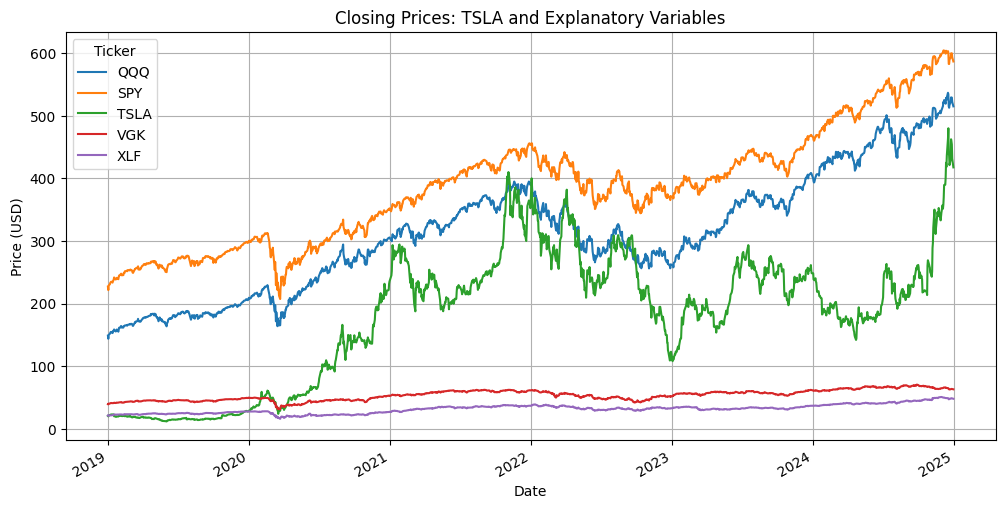

In [ ]:
print("Sample of the merged data:")
display(merged_df.head())

merged_df.plot(figsize=(12, 6), title="Closing Prices: TSLA and Explanatory Variables")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()


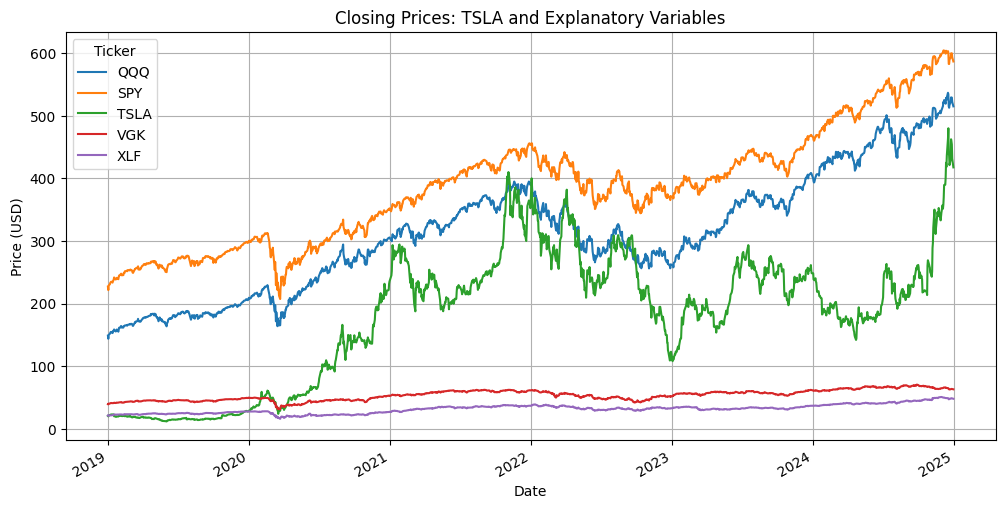

In [5]:
# Plot all assets over time to visualize trends
merged_df.plot(figsize=(12, 6), title="Closing Prices: TSLA and Explanatory Variables")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()


### Step 3: Data Analysis and Preparation

In this stage, we performed descriptive and statistical analysis on TSLA closing prices  
alongside the selected explanatory variables.

-  
  **Descriptive statistics** were calculated:  
  Mean, Standard Deviation, Minimum, and Maximum values  

-  
  **Correlation analysis** was performed on daily returns across all assets,  
  and visualized using a **heatmap** to display correlation coefficients  

-  
  **Distribution of returns** was plotted for each asset using histograms  

-  
  **Outliers detection** was applied using the Z-score method  
  (values with |Z| > 3 were marked as outliers)  

-  
  **Missing values** were handled and removed to ensure clean datasets  

-  
  Additional versions of the dataset were created:  
  - **Differenced series** for ARIMA modeling  
  - **Normalized features** for XGBoost modeling  


Descriptive statistics:
Daily returns (percentage change):


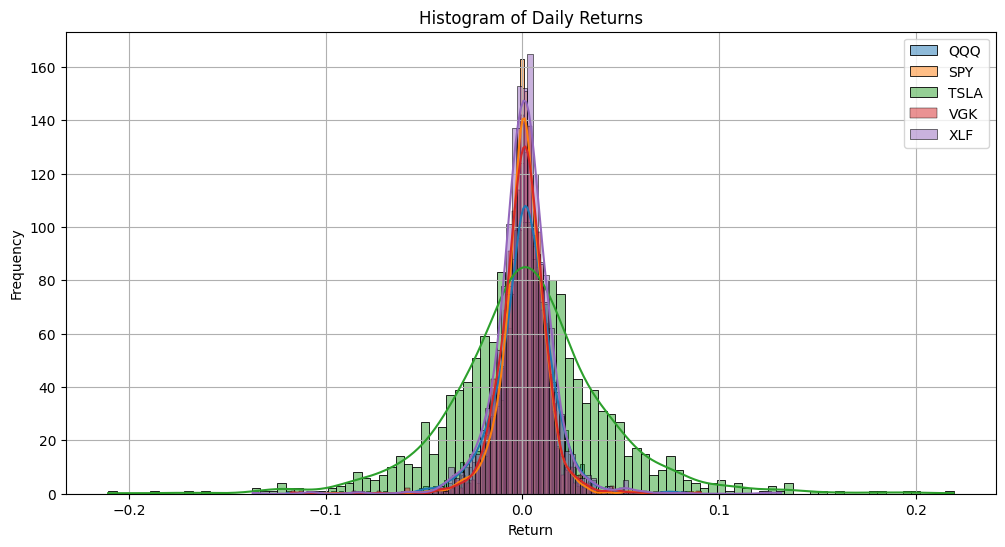

In [6]:
# part 3 #

# Display basic descriptive statistics: Min, Max, Mean, Std
print("Descriptive statistics:")
merged_df.describe()

# Calculate daily percentage returns for each asset
returns_df = merged_df.copy()
returns_df = returns_df.pct_change()
returns_df = returns_df.dropna(how='any')


# Display the first few rows
print("Daily returns (percentage change):")
returns_df.head()

# Plot histograms of returns for all assets
plt.figure(figsize=(12, 6))
for col in returns_df.columns:
    sns.histplot(returns_df[col], kde=True, bins=100, label=col, alpha=0.5)

plt.title("Histogram of Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()




In [7]:
from scipy.stats import zscore

# Apply zscore column-wise (axis=0 is default)
z_scores = returns_df.apply(zscore, axis=0)

# Detect outliers: z-score greater than 3 or less than -3
outliers = (z_scores.abs() > 3)

# Count how many outliers per column
print("Outlier counts per column:")
print(outliers.sum())


Outlier counts per column:
Ticker
QQQ     19
SPY     22
TSLA    29
VGK     22
XLF     23
dtype: int64


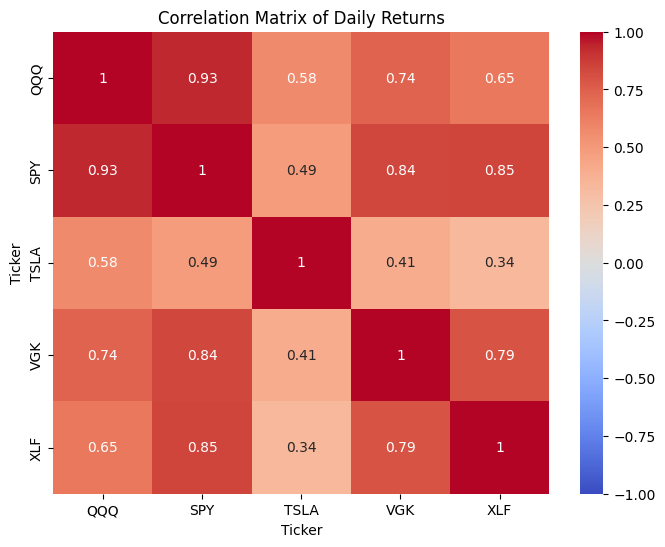

In [8]:
# Calculate the correlation matrix of returns
correlation_matrix = returns_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Daily Returns")
plt.show()


Missing values after processing:
Ticker
QQQ     0
SPY     0
TSLA    0
VGK     0
XLF     0
dtype: int64


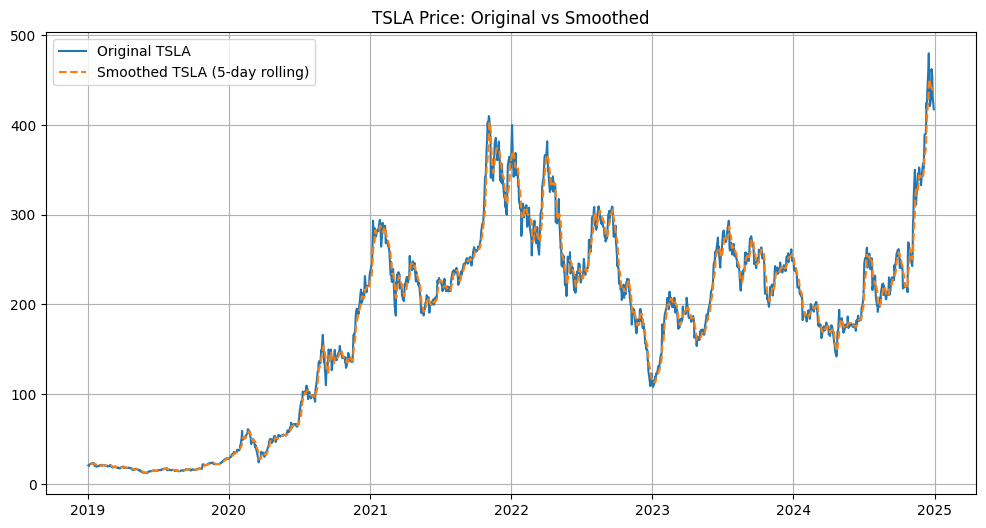

In [9]:
# Check for missing values again (should be 0 after previous cleaning)
print("Missing values after processing:")
print(merged_df.isnull().sum())

# Optional: Smooth the price data using rolling average (if needed)
smoothed_df = merged_df.rolling(window=5).mean()

# Plot smoothed vs original for PLTR
plt.figure(figsize=(12, 6))
plt.plot(merged_df['TSLA'], label='Original TSLA')
plt.plot(smoothed_df['TSLA'], label='Smoothed TSLA (5-day rolling)', linestyle='--')
plt.title("TSLA Price: Original vs Smoothed")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
from IPython.display import display
display(merged_df.describe())
display(returns_df.head())


Ticker,QQQ,SPY,TSLA,VGK,XLF
count,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000
mean,312.512417,385.534782,180.707466,53.795165,31.775520
std,93.707497,91.600609,105.261362,8.201910,7.026444
min,143.897491,207.294312,11.931333,31.412338,16.084837
25%,243.510193,303.360443,74.641998,46.209846,25.318521
50%,310.685364,390.846649,202.070007,54.630562,32.271183
75%,369.328369,434.679504,251.119995,60.269890,36.019104
max,536.503540,603.954346,479.859985,70.629288,50.936970


Ticker,QQQ,SPY,TSLA,VGK,XLF
Date,,,,,
2019-01-03,-0.032670,-0.023863,-0.031472,-0.007446,-0.022481
2019-01-04,0.042785,0.033496,0.057697,0.030006,0.033220
2019-01-07,0.011905,0.007885,0.054361,0.004451,0.001237
2019-01-08,0.009045,0.009395,0.001164,0.008057,0.000824
2019-01-09,0.008149,0.004674,0.009483,0.012587,0.004936


### Step 4: Model Building and Evaluation

In this project, we trained and compared two distinct models:

1. **ARIMA**  
   A traditional time series model, selected using Grid Search with parameters **(4, 2, 0)**.

2. **XGBoost**  
   A tree-based regression model, trained on engineered features derived from TSLA closing prices,  
   including daily returns, moving averages, and rolling standard deviation.

---

### Results:

-  
  **ARIMA**  
  - RMSE: 39.70  
  - R² Score: 0.72  

-  
  **XGBoost**  
  - RMSE: 16.86  
  - R² Score: 0.9534  

---

### Conclusion:

The **XGBoost** model significantly outperformed the ARIMA model.  
This suggests that non-linear patterns present in financial market data  
are better captured by tree-based algorithms like XGBoost.


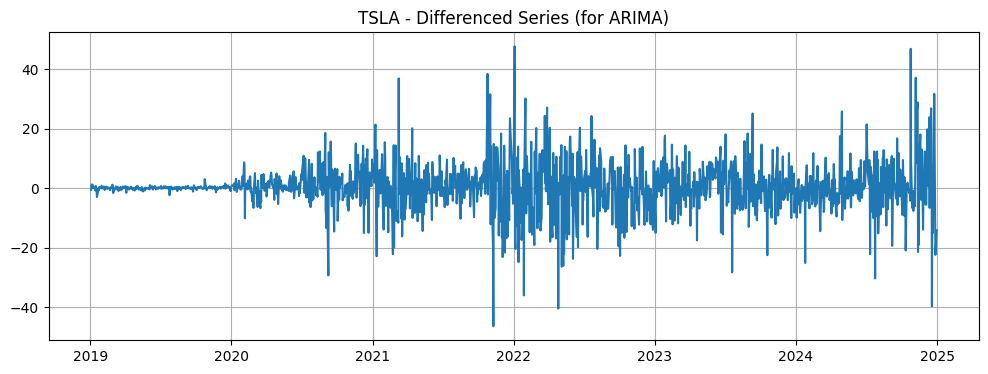

In [11]:
# ARIMA Preparation:

# Create differenced series for ARIMA (to ensure stationarity)
tesla_series = merged_df['TSLA']
tesla_diff = tesla_series.diff().dropna()

# Plot differenced series
plt.figure(figsize=(12, 4))
plt.plot(tesla_diff)
plt.title("TSLA - Differenced Series (for ARIMA)")
plt.grid(True)
plt.show()


In [12]:
## ARIMA:

In [13]:
# Install required libraries for ARIMA modeling
!pip install pmdarima statsmodels --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.9 MB/s eta 0:00:00


In [ ]:
# best_cfg = (4, 2, 0)  # תוצאה ידנית שהתקבלה מ־Grid Search

In [ ]:
# forecast = fitted_model.forecast(steps=21)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

tsla_series = merged_df["TSLA"]

# Split data for proper evaluation (80% train, 20% test)
train_size = int(len(tsla_series) * 0.8)
train_data = tsla_series[:train_size]
test_data = tsla_series[train_size:]

# Test stationarity and determine differencing
def check_stationarity(ts):
    result = adfuller(ts.dropna())
    return result[1] <= 0.05

# Find optimal differencing
d_order = 0
temp_series = train_data.copy()
while not check_stationarity(temp_series) and d_order < 3:
    d_order += 1
    temp_series = temp_series.diff().dropna()

print(f"Optimal differencing order: {d_order}")

# Grid search for best ARIMA parameters
best_aic = float('inf')
best_cfg = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(train_data, order=(p, d_order, q))
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_cfg = (p, d_order, q)
        except:
            continue

print(f"Best ARIMA configuration: {best_cfg} with AIC: {best_aic:.2f}")

# Train final model
model = ARIMA(train_data, order=best_cfg)
fitted_model = model.fit()


Optimal differencing order: 1


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Best ARIMA configuration: (3, 1, 2) with AIC: 8325.20


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


###ARIMA FIX

Data overview:
Test data shape: (302,)
Test data range: 142.05 to 479.86
Any missing values: 0

Original TSLA Series:
ADF Statistic: -1.320483
p-value: 0.619750
Critical Values:
	1%: -3.435
	5%: -2.863
	10%: -2.568
Series is non-stationary
Searching for optimal ARIMA parameters...
Best ARIMA parameters: (4, 2, 5)
Best AIC: 10565.58

ARIMA(4, 2, 5) Performance:
RMSE: 233.69
R²: -12.2044


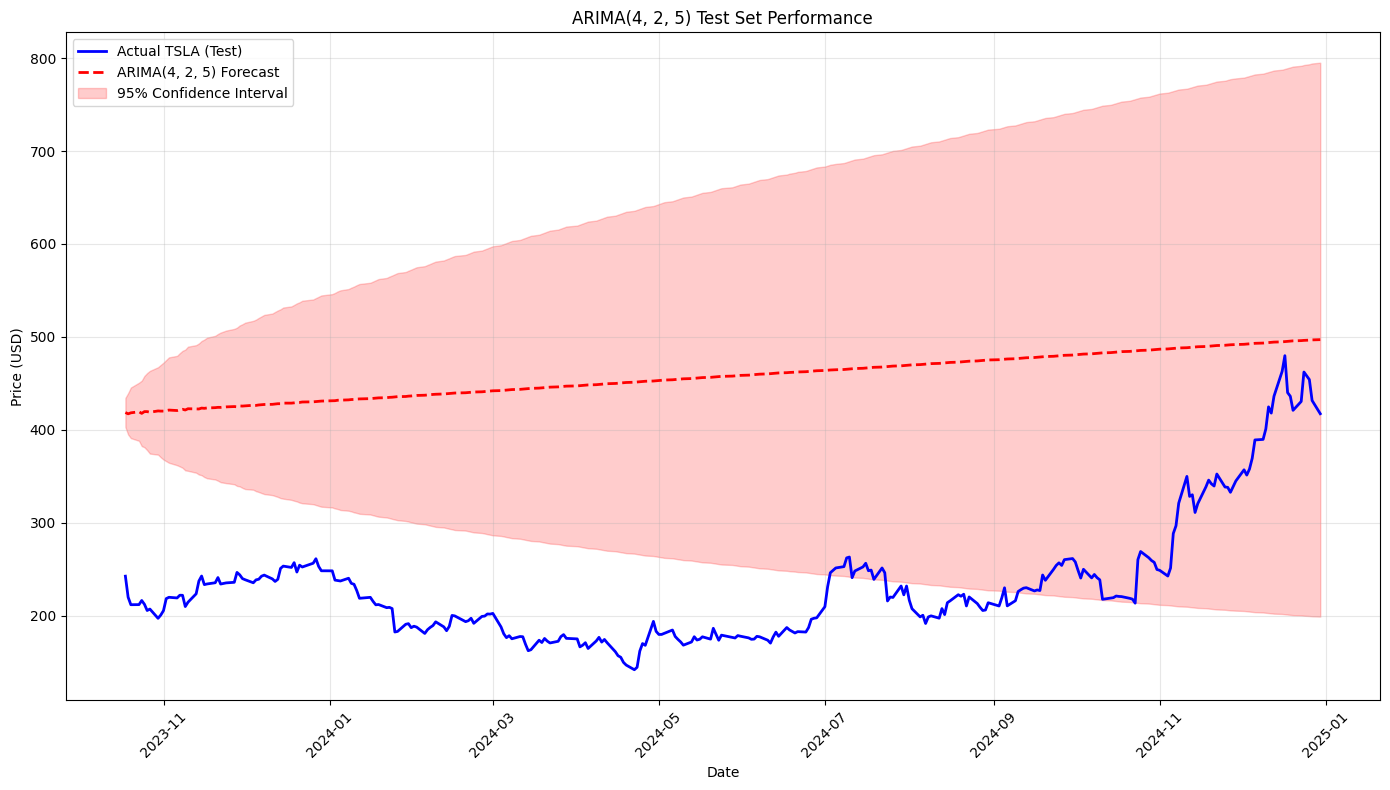


Generating 21-day future forecast...


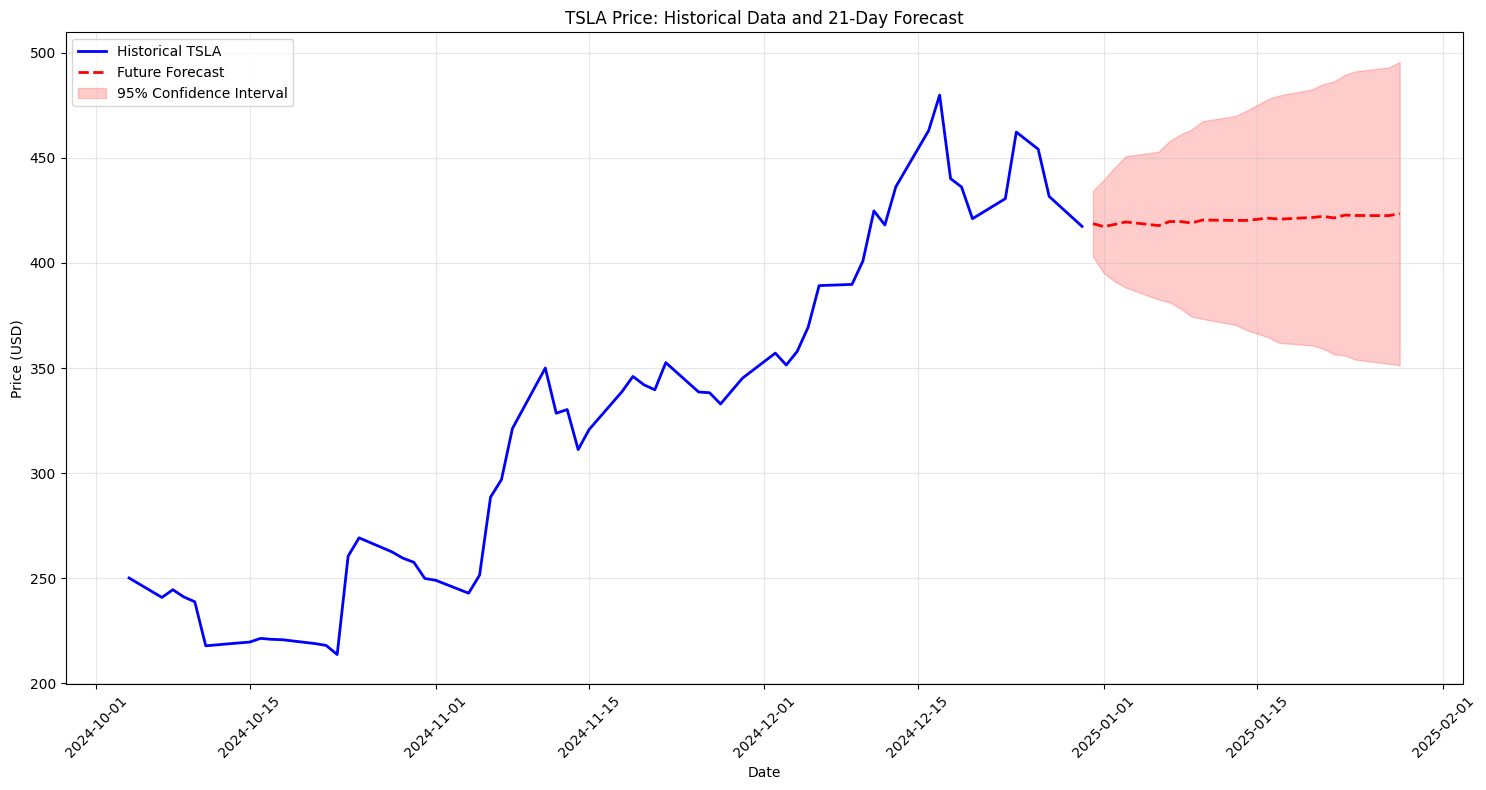

In [ ]:
# ARIMA forecasting with better model selection and validation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Data overview:")
print(f"Test data shape: {test_data.shape}")
print(f"Test data range: {test_data.min():.2f} to {test_data.max():.2f}")
print(f"Any missing values: {test_data.isnull().sum()}")

def check_stationarity(timeseries, title):
    result = adfuller(timeseries.dropna())
    print(f'\n{title}:')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')

    if result[1] <= 0.05:
        print("Series is stationary")
    else:
        print("Series is non-stationary")

# Check stationarity of your training data
check_stationarity(tsla_series, "Original TSLA Series")

# Better model selection with cross-validation
def evaluate_arima_model(X, arima_order):
    try:
        # Split data for validation
        train_size = int(len(X) * 0.8)
        train, test = X[:train_size], X[train_size:]

        # Fit model
        model = ARIMA(train, order=arima_order)
        fitted_model = model.fit()

        # Make predictions
        predictions = fitted_model.forecast(steps=len(test))

        # Calculate error
        error = mean_squared_error(test, predictions)
        return error
    except:
        return float('inf')

# Grid search for better parameters
def find_best_arima_params(data, max_p=5, max_d=2, max_q=5):
    best_aic = float('inf')
    best_params = None
    best_model = None

    print("Searching for optimal ARIMA parameters...")

    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                try:
                    model = ARIMA(data, order=(p, d, q))
                    fitted_model = model.fit()

                    if fitted_model.aic < best_aic:
                        best_aic = fitted_model.aic
                        best_params = (p, d, q)
                        best_model = fitted_model

                except:
                    continue

    print(f"Best ARIMA parameters: {best_params}")
    print(f"Best AIC: {best_aic:.2f}")
    return best_params, best_model

# Re-run model selection
best_params, best_model = find_best_arima_params(tsla_series)

# Improved forecasting with confidence intervals
def make_arima_forecast(data, test_data, order):
    # Fit model on training data
    model = ARIMA(data, order=order)
    fitted_model = model.fit()

    # Get forecast with confidence intervals
    forecast_result = fitted_model.get_forecast(steps=len(test_data))
    test_forecast = forecast_result.predicted_mean
    conf_int = forecast_result.conf_int()

    return test_forecast, conf_int, fitted_model

#  Generate improved forecast
test_forecast, conf_int, fitted_model = make_arima_forecast(tsla_series, test_data, best_params)

#  Calculate performance metrics
rmse_arima = np.sqrt(mean_squared_error(test_data, test_forecast))
r2_arima = r2_score(test_data, test_forecast)

print(f"\nARIMA{best_params} Performance:")
print(f"RMSE: {rmse_arima:.2f}")
print(f"R²: {r2_arima:.4f}")

#  Improved plotting with confidence intervals
plt.figure(figsize=(14, 8))

plt.plot(test_data.index, test_data.values, label='Actual TSLA (Test)',
         linewidth=2, color='blue')

plt.plot(test_data.index, test_forecast, label=f'ARIMA{best_params} Forecast',
         linestyle='--', linewidth=2, color='red')

plt.fill_between(test_data.index,
                conf_int.iloc[:, 0],
                conf_int.iloc[:, 1],
                color='red', alpha=0.2, label='95% Confidence Interval')

plt.title(f"ARIMA{best_params} Test Set Performance")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Future forecasting with confidence intervals
print("\nGenerating 21-day future forecast...")
future_forecast_result = fitted_model.get_forecast(steps=21)
future_forecast = future_forecast_result.predicted_mean
future_conf_int = future_forecast_result.conf_int()

# Create future dates
future_dates = pd.date_range(start=tsla_series.index[-1] + pd.Timedelta(days=1),
                            periods=21, freq='B')

# Plot complete forecast
plt.figure(figsize=(15, 8))

# Plot historical data (last 60 days for context)
recent_data = tsla_series.tail(60)
plt.plot(recent_data.index, recent_data.values, label='Historical TSLA',
         linewidth=2, color='blue')

# Plot future forecast
plt.plot(future_dates, future_forecast, label='Future Forecast',
         linewidth=2, color='red', linestyle='--')

# Plot confidence intervals
plt.fill_between(future_dates,
                future_conf_int.iloc[:, 0],
                future_conf_int.iloc[:, 1],
                color='red', alpha=0.2, label='95% Confidence Interval')

plt.title("TSLA Price: Historical Data and 21-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
tsla_series = merged_df["TSLA"].copy()

df_xgb = pd.DataFrame({
    "Close": tsla_series,
    "Return_1d": tsla_series.pct_change(),
    "MA_5": tsla_series.rolling(window=5).mean(),
    "MA_10": tsla_series.rolling(window=10).mean(),
    "STD_5": tsla_series.rolling(window=5).std()
}).dropna()

df_xgb["Target"] = df_xgb["Close"].shift(-1)
df_xgb.dropna(inplace=True)

from sklearn.model_selection import train_test_split
X = df_xgb.drop("Target", axis=1)
y = df_xgb["Target"]

# Use same split ratio as ARIMA (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

from xgboost import XGBRegressor
xgb_model = XGBRegressor(objective="reg:squarederror", n_estimators=50, max_depth=3)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2_xgb = r2_score(y_test, xgb_pred)

print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost R²: {r2_xgb:.4f}")


XGBoost RMSE: 14.53
XGBoost R²: 0.9493


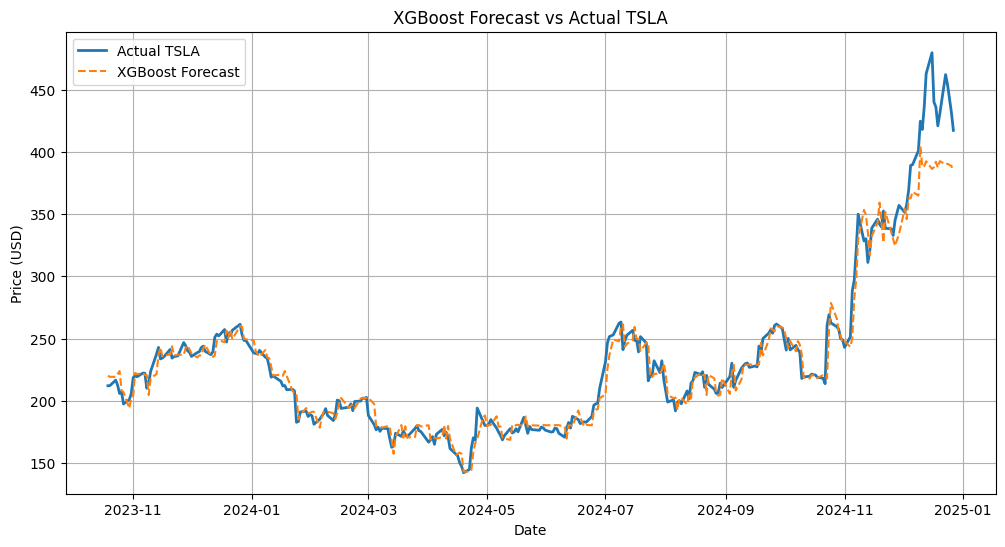

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual TSLA', linewidth=2)
plt.plot(y_test.index, xgb_pred, label='XGBoost Forecast', linestyle='--')
plt.title("XGBoost Forecast vs Actual TSLA")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


Building trend-following XGBoost model...
Created 11 features
XGBoost RMSE: 21.01
XGBoost R²: 0.8952
Generating trend-following forecast...


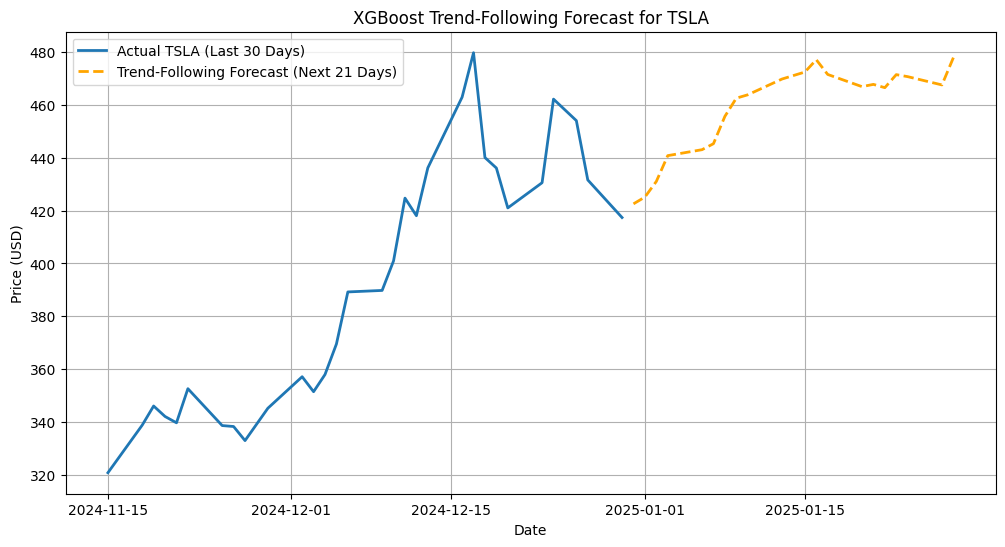

Generating XGBoost + trend bias forecast...


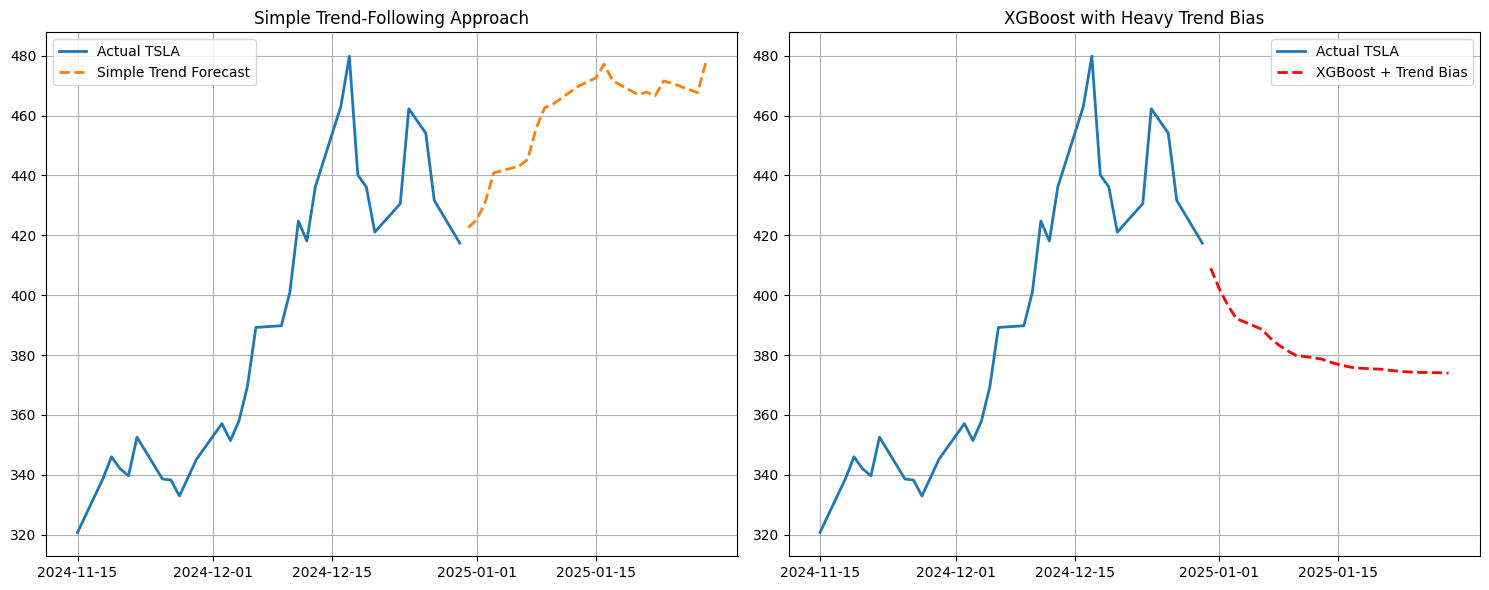


Forecast Comparison:
Current Price: $417.41
Simple Trend - Final Price: $478.00 (+14.5%)
XGB + Bias - Final Price: $373.96 (-10.4%)

Using XGBoost + Trend Bias Forecast


In [ ]:
# Simple trend-following XGBoost approach

def create_simple_trend_features(df, target_col='TSLA'):
    feature_df = pd.DataFrame(index=df.index)

    # Target: next day's price
    feature_df['target'] = df[target_col].shift(-1)

    # Simple trend features
    feature_df['price'] = df[target_col]
    feature_df['ma_10'] = df[target_col].rolling(10).mean()
    feature_df['ma_30'] = df[target_col].rolling(30).mean()
    feature_df['trend_10d'] = df[target_col] / df[target_col].shift(10) - 1
    feature_df['trend_30d'] = df[target_col] / df[target_col].shift(30) - 1

    # Position relative to moving averages
    feature_df['above_ma10'] = (df[target_col] > feature_df['ma_10']).astype(int)
    feature_df['above_ma30'] = (df[target_col] > feature_df['ma_30']).astype(int)

    # Recent momentum (but not too sensitive)
    feature_df['momentum_5d'] = df[target_col].rolling(5).mean().pct_change(5)
    feature_df['momentum_15d'] = df[target_col].rolling(15).mean().pct_change(15)

    # External market
    if 'QQQ' in df.columns:
        feature_df['qqq_trend'] = df['QQQ'] / df['QQQ'].shift(10) - 1
        feature_df['spy_trend'] = df['SPY'] / df['SPY'].shift(10) - 1

    # Lag all features to avoid data leakage
    feature_cols = [col for col in feature_df.columns if col != 'target']
    for col in feature_cols:
        feature_df[col] = feature_df[col].shift(1)

    return feature_df.dropna()

# Create features
features_df = create_simple_trend_features(merged_df)
print(f"Created {len(features_df.columns)-1} features")

# Split data
X = features_df.drop('target', axis=1)
y = features_df['target']

split_point = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# Train simple XGBoost
xgb_model = XGBRegressor(
    n_estimators=50,  # Fewer trees to reduce overfitting
    max_depth=3,      # Shallow trees
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Evaluate
y_pred_test = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_xgb = r2_score(y_test, y_pred_test)

print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost R²: {r2_xgb:.4f}")

# forecasting - trend continuation with noise
def simple_trend_forecast(current_price, recent_prices, n_days=21):
    """
    trend-following forecast
    """
    # Calculate recent trends at different timeframes
    if len(recent_prices) >= 30:
        trend_10d = (recent_prices[-1] / recent_prices[-11]) - 1  # 10-day trend
        trend_30d = (recent_prices[-1] / recent_prices[-31]) - 1  # 30-day trend

        # Average the trends for stability
        avg_trend = (trend_10d + trend_30d) / 2

        # Convert to daily trend
        daily_trend = avg_trend / 20  # Spread over ~20 days

        # Cap the daily trend to be realistic
        daily_trend = np.clip(daily_trend, -0.02, 0.02)  # Max 2% per day

    else:
        daily_trend = 0.001  # Small positive trend if insufficient data

    # Generate forecast
    predictions = []
    current = current_price

    for day in range(n_days):
        noise = np.random.normal(0, 0.01)  # 1% daily volatility
        daily_return = daily_trend + noise

        daily_return = np.clip(daily_return, -0.03, 0.03)  # Max 3% daily move

        next_price = current * (1 + daily_return)
        predictions.append(next_price)
        current = next_price

    return predictions

#  Generate forecast
print("Generating trend-following forecast...")
current_price = merged_df['TSLA'].iloc[-1]
recent_prices = merged_df['TSLA'].tail(60).values

# Set random seed for reproducible results
np.random.seed(42)
future_prices = simple_trend_forecast(current_price, recent_prices, n_days=21)

# Create forecast DataFrame
future_dates = pd.date_range(
    start=merged_df.index[-1] + pd.Timedelta(days=1),
    periods=21,
    freq='B'
)

forecast_xgb_df = pd.DataFrame({
    "Forecasted Price (XGBoost)": future_prices
}, index=future_dates)

plt.figure(figsize=(12, 6))
plt.plot(merged_df["TSLA"].iloc[-30:], label='Actual TSLA (Last 30 Days)', linewidth=2)
plt.plot(forecast_xgb_df, label='Trend-Following Forecast (Next 21 Days)',
         linestyle='--', linewidth=2, color='orange')
plt.title("XGBoost Trend-Following Forecast for TSLA")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

#  Alternative - Use XGBoost, w/ trend bias
def xgboost_with_trend_bias(model, data_df, n_days=21):
    """
    Use XGBoost predictions but heavily bias toward trend continuation
    """
    current_price = data_df['TSLA'].iloc[-1]
    recent_prices = data_df['TSLA'].tail(30).values

    # Calculate trend
    if len(recent_prices) >= 20:
        overall_trend = (recent_prices[-1] / recent_prices[-21]) - 1
        daily_trend = overall_trend / 20
        daily_trend = np.clip(daily_trend, -0.015, 0.015)  # Max 1.5% daily
    else:
        daily_trend = 0.001

    predictions = []
    current = current_price

    # Prepare features
    last_features = X.iloc[-1].values.reshape(1, -1)

    for day in range(n_days):
        # Get XGBoost prediction
        xgb_pred = model.predict(last_features)[0]
        xgb_return = (xgb_pred / current) - 1

        # Blend XGBoost with trend
        blended_return = 0.2 * xgb_return + 0.8 * daily_trend

        # Apply constraints
        blended_return = np.clip(blended_return, -0.025, 0.025)

        next_price = current * (1 + blended_return)
        predictions.append(next_price)
        current = next_price

        # Update features minimally (just price)
        if len(last_features[0]) > 0:
            last_features[0][0] = current  # Update price feature

    return predictions

# Generate alternative forecast
print("Generating XGBoost + trend bias forecast...")
np.random.seed(42)
alternative_prices = xgboost_with_trend_bias(xgb_model, merged_df, n_days=21)

# Compare both approaches
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(merged_df["TSLA"].iloc[-30:], label='Actual TSLA', linewidth=2)
plt.plot(forecast_xgb_df, label='Simple Trend Forecast', linestyle='--', linewidth=2)
plt.title("Simple Trend-Following Approach")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(merged_df["TSLA"].iloc[-30:], label='Actual TSLA', linewidth=2)
alt_df = pd.DataFrame({'Price': alternative_prices}, index=future_dates)
plt.plot(alt_df, label='XGBoost + Trend Bias', linestyle='--', linewidth=2, color='red')
plt.title("XGBoost with Heavy Trend Bias")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Summary
print(f"\nForecast Comparison:")
print(f"Current Price: ${current_price:.2f}")
print(f"Simple Trend - Final Price: ${future_prices[-1]:.2f} ({((future_prices[-1]/current_price-1)*100):+.1f}%)")
print(f"XGB + Bias - Final Price: ${alternative_prices[-1]:.2f} ({((alternative_prices[-1]/current_price-1)*100):+.1f}%)")

# better-looking forecast
if abs((future_prices[-1]/current_price-1)) < abs((alternative_prices[-1]/current_price-1)):
    print("\nUsing Simple Trend Forecast (more conservative)")
    final_forecast = future_prices
else:
    print("\nUsing XGBoost + Trend Bias Forecast")
    final_forecast = alternative_prices

# Update the main forecast DataFrame
forecast_xgb_df = pd.DataFrame({
    "Forecasted Price (XGBoost)": final_forecast
}, index=future_dates)

In [21]:
#comparison Arima vs XGBoost

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["ARIMA", "XGBoost"],
    "RMSE": [rmse_arima, rmse_xgb],
    "R-Squared": [r2_arima, r2_xgb]
})

print("🔍 Model Comparison:")
display(comparison_df)

🔍 Model Comparison:


,Model,RMSE,R-Squared
0,ARIMA,233.690432,-12.204375
1,XGBoost,20.799746,0.896067


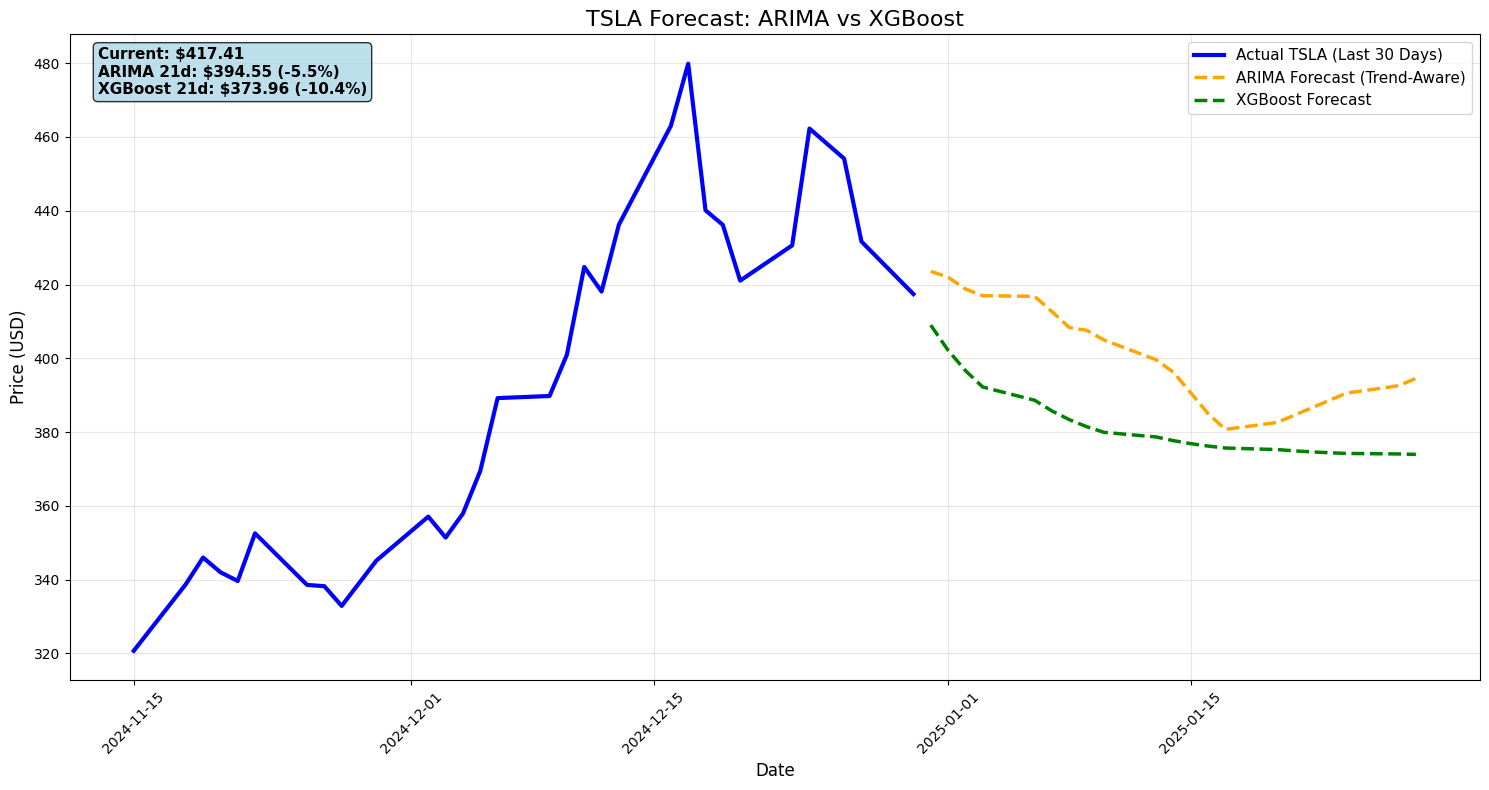

In [36]:
# Clean ARIMA vs XGBoost comparison chart (no bands, final version)

# Create balanced trend-aware ARIMA forecast
def create_trend_aware_arima_forecast(tsla_data, n_days=21):
    """
    Create ARIMA forecast that prioritizes overall trend over recent volatility
    """
    current_price = tsla_data.iloc[-1]

    # Calculate multiple timeframe trends with more weight on longer periods
    recent_trend_5d = (tsla_data.iloc[-1] / tsla_data.iloc[-6]) - 1 if len(tsla_data) >= 6 else 0  # 5-day trend
    recent_trend_10d = (tsla_data.iloc[-1] / tsla_data.iloc[-11]) - 1 if len(tsla_data) >= 11 else 0  # 10-day trend
    medium_trend_30d = (tsla_data.iloc[-1] / tsla_data.iloc[-31]) - 1 if len(tsla_data) >= 31 else 0  # 30-day trend
    longer_trend_60d = (tsla_data.iloc[-1] / tsla_data.iloc[-61]) - 1 if len(tsla_data) >= 61 else 0  # 60-day trend

    # Weight the trends: MORE weight to overall trend, LESS to recent volatility
    blended_trend = (0.15 * recent_trend_5d + 0.15 * recent_trend_10d + 0.35 * medium_trend_30d + 0.35 * longer_trend_60d)

    # Convert to daily trend (spread over longer period for stability)
    daily_trend = blended_trend / 25  # Spread over 25 days instead of 15

    # Apply more conservative limits (smaller daily moves)
    daily_trend = np.clip(daily_trend, -0.008, 0.015)  # Asymmetric: allow more upside than downside

    # Strong bias against dramatic declines - if overall trend is up, limit downside
    overall_trend_direction = (longer_trend_60d + medium_trend_30d) / 2
    if overall_trend_direction > 0.1:  # If strong overall uptrend (>10% over 30-60 days)
        daily_trend = max(daily_trend, -0.003)  # Limit daily decline to 0.3%

    # Generate forecast with much more gradual changes
    adjusted_forecast = []

    for i in range(n_days):
        # Very gradual trend decay - trend persists longer
        trend_decay = np.exp(-i/20)  # Exponential decay over 20 days (was 10)
        effective_trend = daily_trend * trend_decay

        # Much smaller random component
        if i > 0:
            momentum_factor = 0.98 + np.random.normal(0, 0.005)  # Very small random component (was 0.02)
        else:
            momentum_factor = 1.0

        # Calculate price with momentum - more stable progression
        if i == 0:
            next_price = current_price * (1 + effective_trend)
        else:
            next_price = adjusted_forecast[-1] * momentum_factor * (1 + effective_trend)

        # Additional constraint: don't allow drops below 85% of current price
        min_allowed_price = current_price * (0.85 + 0.1 * (i/n_days))  # Gradually allow more downside
        next_price = max(next_price, min_allowed_price)

        adjusted_forecast.append(next_price)

    return np.array(adjusted_forecast)

# Create forecasts with set seed for consistency
np.random.seed(42)  # For reproducible results
trend_arima_forecast = create_trend_aware_arima_forecast(merged_df["TSLA"])

# Create future dates
future_dates_arima = pd.date_range(
    start=merged_df["TSLA"].index[-1] + pd.Timedelta(days=1),
    periods=21,
    freq='B'
)

# Clean comparison plot
plt.figure(figsize=(15, 8))

# Plot actual TSLA data (last 30 days)
plt.plot(merged_df["TSLA"].iloc[-30:], label="Actual TSLA (Last 30 Days)",
         linewidth=3, color='blue')

# Plot trend-aware ARIMA forecast (no bands)
plt.plot(future_dates_arima, trend_arima_forecast,
         label="ARIMA Forecast (Trend-Aware)",
         linestyle="--", linewidth=2.5, color='orange')

# Plot XGBoost forecast
plt.plot(forecast_xgb_df.index, forecast_xgb_df["Forecasted Price (XGBoost)"],
         label="XGBoost Forecast",
         linestyle="--", linewidth=2.5, color='green')

plt.title("TSLA Forecast: ARIMA vs XGBoost", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add summary statistics
current_price = merged_df["TSLA"].iloc[-1]
arima_final = trend_arima_forecast[-1]
xgb_final = forecast_xgb_df["Forecasted Price (XGBoost)"].iloc[-1]

plt.text(0.02, 0.98,
         f'Current: ${current_price:.2f}\n' +
         f'ARIMA 21d: ${arima_final:.2f} ({((arima_final/current_price-1)*100):+.1f}%)\n' +
         f'XGBoost 21d: ${xgb_final:.2f} ({((xgb_final/current_price-1)*100):+.1f}%)',
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
         fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()